In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\grhar\OneDrive\Documents\Projects\ml-algorithm-comparison\Notebooks
['ml_algorithm_comparison.ipynb']


In [3]:
df = pd.read_csv("../data/churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df.dropna(inplace=True)

In [14]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=["object"]).columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

C:\Users\grhar\AppData\Local\Temp\ipykernel_32708\1329739017.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


In [15]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [20]:
results = []

In [21]:
for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print(f"{name} completed.")

Logistic Regression completed.
Decision Tree completed.
Random Forest completed.
KNN completed.
SVM completed.
Naive Bayes completed.


In [22]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.785359,0.620805,0.494652,0.550595,0.830738
1,Decision Tree,0.724947,0.483951,0.524064,0.503209,0.659638
2,Random Forest,0.790334,0.640569,0.481283,0.549618,0.813892
3,KNN,0.740583,0.512064,0.510695,0.511379,0.757250
4,SVM,0.791045,0.652672,0.457219,0.537736,0.778561
5,Naive Bayes,0.737740,0.504638,0.727273,0.595838,0.812689


In [23]:
results_df.to_csv("results.csv", index=False)

In [24]:
best_model = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.785359,0.620805,0.494652,0.550595,0.830738
2,Random Forest,0.790334,0.640569,0.481283,0.549618,0.813892
5,Naive Bayes,0.737740,0.504638,0.727273,0.595838,0.812689
4,SVM,0.791045,0.652672,0.457219,0.537736,0.778561
3,KNN,0.740583,0.512064,0.510695,0.511379,0.757250
1,Decision Tree,0.724947,0.483951,0.524064,0.503209,0.659638


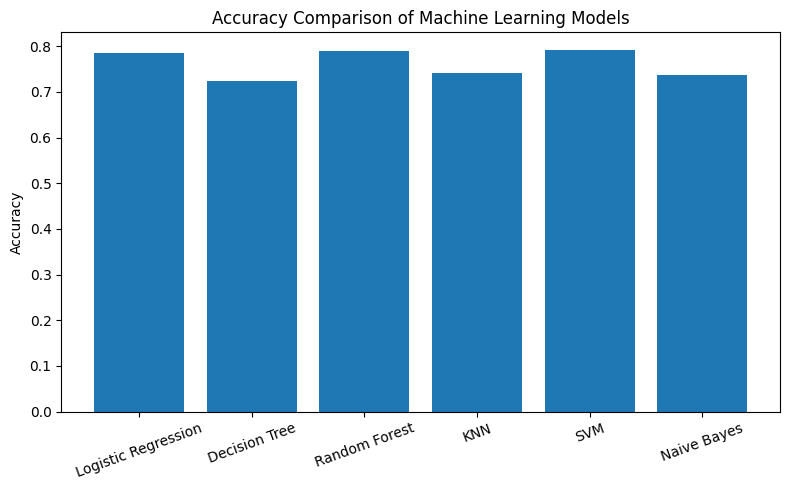

In [25]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("../assets/accuracy_comparison.png", dpi=300)

plt.show()

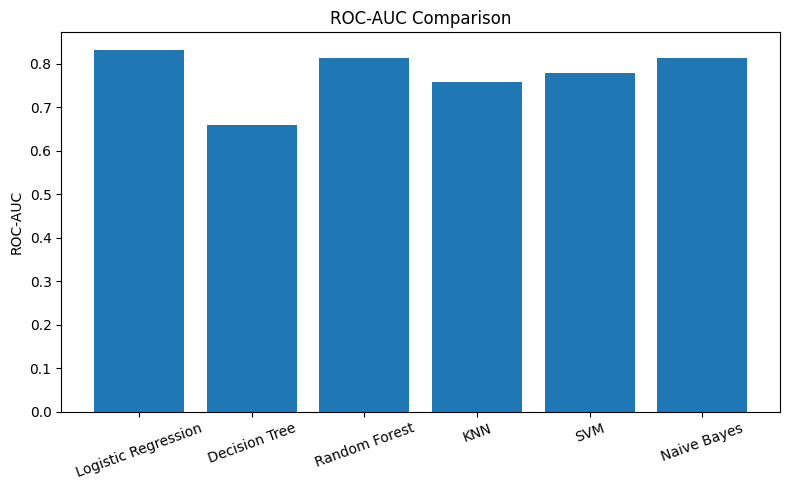

In [26]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["ROC-AUC"])

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("../assets/roc_auc_comparison.png", dpi=300)

plt.show()

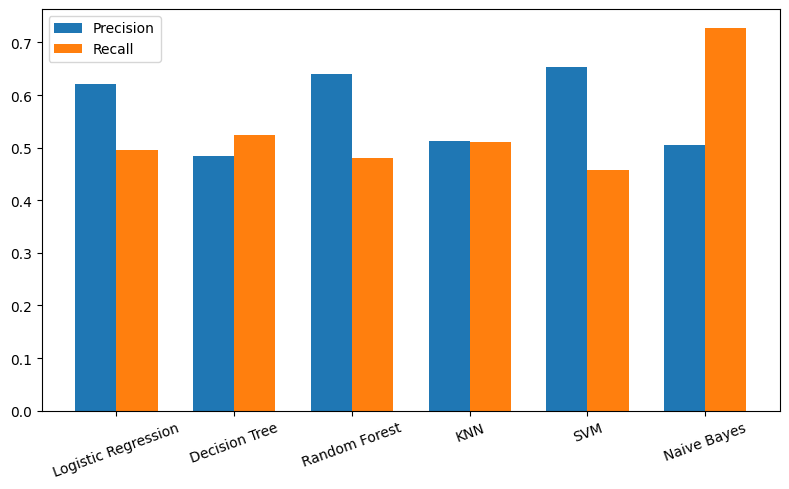

In [27]:
x = np.arange(len(results_df))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x-width/2,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x+width/2,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.xticks(x, results_df["Model"], rotation=20)

plt.legend()

plt.tight_layout()

plt.savefig("../assets/precision_recall.png", dpi=300)

plt.show()

In [28]:
best_model = LogisticRegression(random_state=42)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

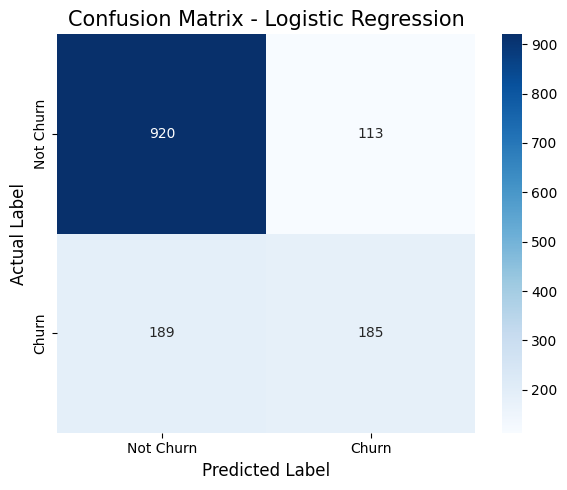

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=15)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.tight_layout()

plt.savefig("../assets/confusion_matrix.png", dpi=300)

plt.show()

In [30]:
import joblib

joblib.dump(models["Logistic Regression"], "../models/logistic_regression.pkl")

joblib.dump(models["Decision Tree"], "../models/decision_tree.pkl")

joblib.dump(models["Random Forest"], "../models/random_forest.pkl")

joblib.dump(models["KNN"], "../models/knn.pkl")

joblib.dump(models["SVM"], "../models/svm.pkl")

joblib.dump(models["Naive Bayes"], "../models/naive_bayes.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

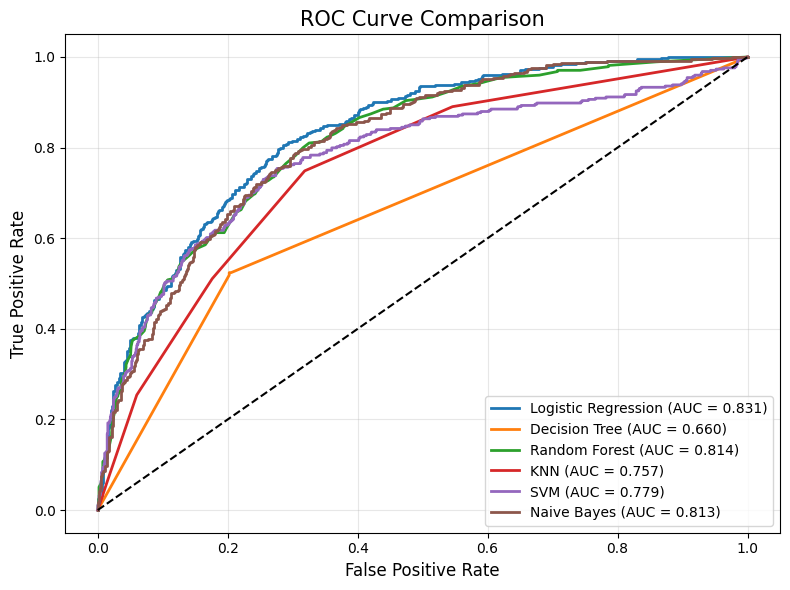

In [31]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate",fontsize=12)
plt.ylabel("True Positive Rate",fontsize=12)

plt.title("ROC Curve Comparison",fontsize=15)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../assets/roc_curve_all_models.png",dpi=300)

plt.show()

In [32]:
import os
from sklearn.metrics import classification_report

os.makedirs("../classification_reports", exist_ok=True)

for name, model in models.items():

    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred)

    filename = name.lower().replace(" ","_")

    with open(f"../classification_reports/{filename}.txt","w") as f:
        f.write(report)

In [33]:
display_results = results_df.copy()

for col in display_results.columns[1:]:

    display_results[col] = (display_results[col]*100).round(2)

display_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,78.54,62.08,49.47,55.06,83.07
1,Decision Tree,72.49,48.40,52.41,50.32,65.96
2,Random Forest,79.03,64.06,48.13,54.96,81.39
3,KNN,74.06,51.21,51.07,51.14,75.73
4,SVM,79.10,65.27,45.72,53.77,77.86
5,Naive Bayes,73.77,50.46,72.73,59.58,81.27


In [34]:
ranking = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

ranking.index += 1

ranking

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.785359,0.620805,0.494652,0.550595,0.830738
2,Random Forest,0.790334,0.640569,0.481283,0.549618,0.813892
3,Naive Bayes,0.737740,0.504638,0.727273,0.595838,0.812689
4,SVM,0.791045,0.652672,0.457219,0.537736,0.778561
5,KNN,0.740583,0.512064,0.510695,0.511379,0.757250
6,Decision Tree,0.724947,0.483951,0.524064,0.503209,0.659638


In [36]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
18,TotalCharges,0.184953
17,MonthlyCharges,0.178014
4,tenure,0.154510
14,Contract,0.080585
16,PaymentMethod,0.052031
8,OnlineSecurity,0.048509
11,TechSupport,0.047581
7,InternetService,0.026813
0,gender,0.026715
9,OnlineBackup,0.025883


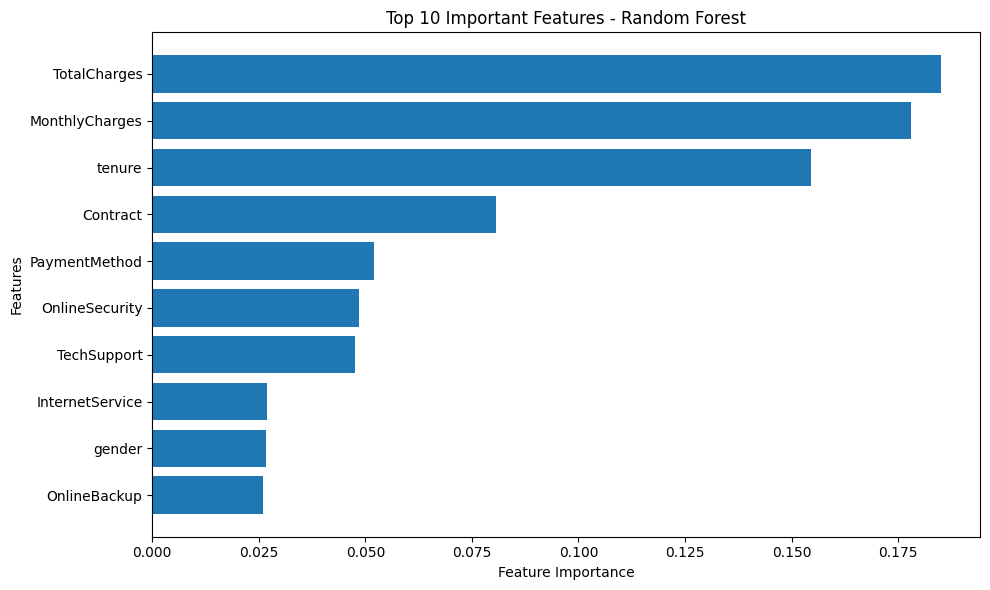

In [38]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.title("Top 10 Important Features - Random Forest")

plt.tight_layout()

plt.savefig(
    "../assets/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()